In [4]:
!nvidia-smi

Wed Apr 29 22:47:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLOv8

YOLOv8 can be installed in two ways - from the source and via pip. This is because it is the first iteration of YOLO to have an official package.

In [6]:
# Pip install method (recommended)

!pip install ultralytics -U -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)


In [7]:
from ultralytics import YOLO

from IPython.display import display, Image

In [8]:
!pip install roboflow
from roboflow import Roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 37.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [9]:
!mkdir -p /content/datasets/cctv_people
%cd /content/datasets/cctv_people
!curl -L "https://app.roboflow.com/ds/ECBsZejMmv?key=Jcqa6riZ4j" > roboflow.zip;
!unzip roboflow.zip;
!rm roboflow.zip


/content/datasets/cctv_people
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   903  100   903    0     0   1448      0 --:--:-- --:--:-- --:--:--  1447
100 53.5M  100 53.5M    0     0  23.8M      0  0:00:02  0:00:02 --:--:-- 51.0M
Archive:  roboflow.zip
 extracting: train/images/CCTV_486_png.rf.fa5a0966d095f4a12d135cd49928577d.jpg  
 extracting: test/images/CCTV_12_png.rf.1d960c5d02369e8aaa05180d18ee403a.jpg  
 extracting: train/images/CCTV_455_png.rf.c88bbea252be55f803a9ffca64d77d0e.jpg  
 extracting: test/images/CCTV_196_png.rf.0b89eb0d746c3ab765f0415dd508ae98.jpg  
 extracting: train/images/CCTV_50_png.rf.88db27ac114cab1e53d7830f1c73b714.jpg  
 extracting: train/images/CCTV_236_png.rf.6e477ce9683d45cc0e825e1c9edd223b.jpg  
 extracting: train/images/CCTV_169_png.rf.9893373675254ef020396a3875ac7156.jpg  
 extracting: test/images/CCTV_60_png.rf.b11c5c2671d407a87a94d9e00185

In [10]:
!pip install pandas
!pip install matplotlib
import pandas as pd
import matplotlib.pyplot as plt


------------------------------training yolov8n--------------------------------------------------------------------------
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/cctv_people/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=520, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.

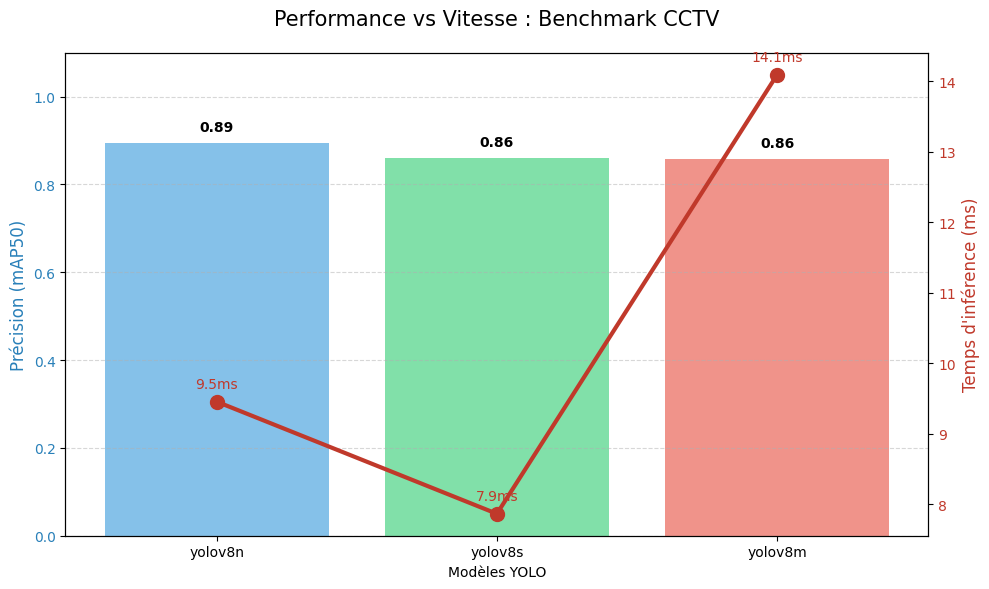

In [11]:
versions=['yolov8n','yolov8s','yolov8m']
results_data = []
path='/content/datasets/cctv_people/data.yaml'
for v in versions:
  model= YOLO(v)
  print(f"------------------------------training {v}--------------------------------------------------------------------------")
  model.train(data='/content/datasets/cctv_people/data.yaml',epochs=15,imgsz=520,device=0,batch=16,name=f'training_{v}',save=True,plots=True,exist_ok=True)

  metrics = model.val(split='test')

  results_data.append({
      'Model': v,
      'mAP50': metrics.results_dict['metrics/mAP50(B)'],
      'mAP50-95': metrics.results_dict['metrics/mAP50-95(B)'],
      'Inference_ms': metrics.speed['inference'],
      'Preprocess_ms': metrics.speed['preprocess'],
      'Postprocess_ms': metrics.speed['postprocess']
  })
df = pd.DataFrame(results_data)
print("\n--- FINAL COMPARISON ---")
print(df)


#-------------visualisation of performance -------------------------

mAP_scores = [d['mAP50'] for d in results_data]
inference_times = [d['Inference_ms'] for d in results_data]
fig, ax1 = plt.subplots(figsize=(10, 6))
color_bars = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax1.bar(versions, mAP_scores, color=color_bars, alpha=0.6, label='mAP50')
ax1.set_xlabel('Modèles YOLO')
ax1.set_ylabel('Précision (mAP50)', color='#2980b9', fontsize=12)
ax1.set_ylim(0, 1.1)
ax1.tick_params(axis='y', labelcolor='#2980b9')
ax2 = ax1.twinx()
ax2.plot(versions, inference_times, color='#c0392b', marker='o', linewidth=3, markersize=10, label='Latence (ms)')
ax2.set_ylabel('Temps d\'inférence (ms)', color='#c0392b', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#c0392b')
plt.title('Performance vs Vitesse : Benchmark CCTV', fontsize=15, pad=20)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
for i, txt in enumerate(inference_times):
    ax2.annotate(f'{txt:.1f}ms', (versions[i], inference_times[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', color='#c0392b')
plt.tight_layout()
plt.show()

------------------------------------------------training yolov8n-----------------------------------------------------------------------------
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/cctv_people/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=520, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, mome

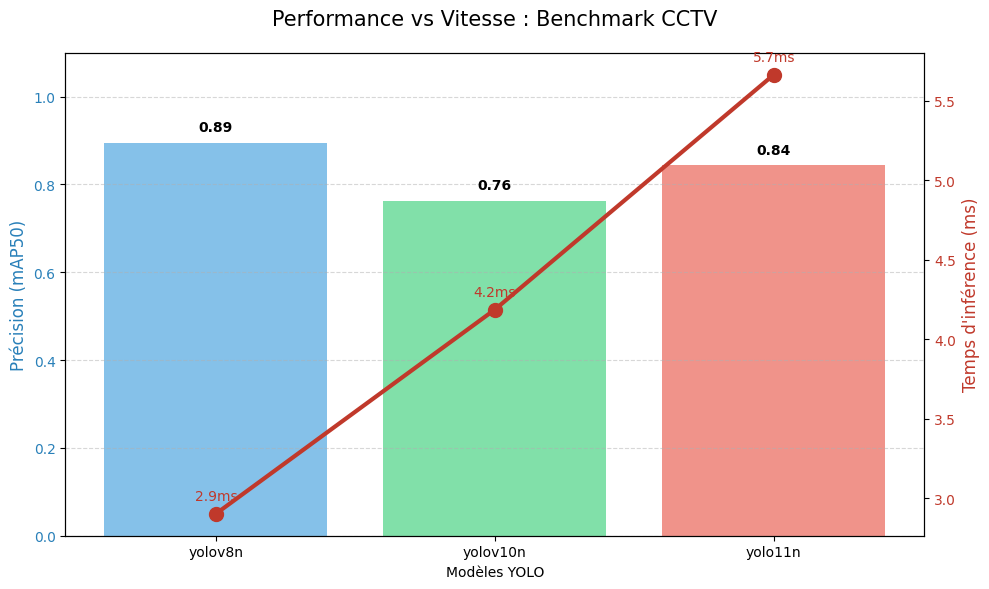

In [12]:
models=['yolov8n','yolov10n','yolo11n']
path='/content/datasets/cctv_people/data.yaml'
results_model=[]
for m in models:
  model= YOLO(m)
  print(f"------------------------------------------------training {m}-----------------------------------------------------------------------------")
  model.train(data='/content/datasets/cctv_people/data.yaml',epochs=15,imgsz=520,device=0,batch=16,name=f'train_{m}',save=True,plots=True,exist_ok=True)

  metrics = model.val(split='test')

  results_model.append({
      'Model': m,
      'mAP50': metrics.results_dict['metrics/mAP50(B)'],
      'mAP50-95': metrics.results_dict['metrics/mAP50-95(B)'],
      'Inference_ms': metrics.speed['inference'],
      'Preprocess_ms': metrics.speed['preprocess'],
      'Postprocess_ms': metrics.speed['postprocess']
  })
df = pd.DataFrame(results_model)
print("\n--- FINAL COMPARISON ---")
print(df)


#-------------visualisation of performance -------------------------

mAP_scores = [d['mAP50'] for d in results_model]
inference_times = [d['Inference_ms'] for d in results_model]
fig, ax1 = plt.subplots(figsize=(10, 6))
color_bars = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax1.bar(models, mAP_scores, color=color_bars, alpha=0.6, label='mAP50')
ax1.set_xlabel('Modèles YOLO')
ax1.set_ylabel('Précision (mAP50)', color='#2980b9', fontsize=12)
ax1.set_ylim(0, 1.1)
ax1.tick_params(axis='y', labelcolor='#2980b9')
ax2 = ax1.twinx()
ax2.plot(models, inference_times, color='#c0392b', marker='o', linewidth=3, markersize=10, label='Latence (ms)')
ax2.set_ylabel('Temps d\'inférence (ms)', color='#c0392b', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#c0392b')
plt.title('Performance vs Vitesse : Benchmark CCTV', fontsize=15, pad=20)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
for i, txt in enumerate(inference_times):
    ax2.annotate(f'{txt:.1f}ms', (models[i], inference_times[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', color='#c0392b')
plt.tight_layout()
plt.show()